# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [4]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3
import inspect

In [2]:
# Initialization

load_dotenv(override=True)

xai_api_key = os.getenv('XAI_API_KEY')
if xai_api_key:
    print(f"XAI API Key exists and begins {xai_api_key[:8]}")
else:
    print("XAI API Key not set")

MODEL = "grok-4-1-fast-non-reasoning"
xai = OpenAI(api_key=xai_api_key, base_url="https://api.x.ai/v1")

DB = "prices.db"

XAI API Key exists and begins xai-XWGi


In [46]:
import requests
import os

response = requests.post(
    "https://api.x.ai/v1/tts",
    headers={
        "Authorization": f"Bearer {xai_api_key}",
        "Content-Type": "application/json",
    },
    json={
        "text": "Hello, this is grok.",
        "voice_id": "ara",      # or eve, rex, sal, leo
        "language": "en"        # or "auto"
    }
)

if response.status_code == 200:
    with open("c:\\temp\\output.mp3", "wb") as f:
        f.write(response.content)
else:
    print(response.json())  # This will likely show the authorization error

Traceback (most recent call last):
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-packages\gradio\queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-packages\gradio\blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-packages\gradio\blocks.py", line 1623, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-p

In [3]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [21]:
from sympy import true


tools = {}

def register_tool(func:callable, description:str):
    """Registers a function as a tool for the LLM to use.

    Parameter types are derived from function annotations, and descriptions are derived from the function docstrings
    Args:
        func (callable): The function to register as a tool.
        description (str): A brief description of what the tool does.
    """
    parameters = {}
    sig = inspect.signature(func)
    for param_name, param in sig.parameters.items():
        parameters[param_name] = {"type": get_property_type(param.annotation, true), "description": get_description(func.__doc__, param_name)}
    tools[func.__name__] = {"function": func,
                             "json": {
                                "name": func.__name__,
                    "description": description,
                    "parameters": {
                        "type": "object",
                        "properties": parameters,
                    },
                    "required": [
                        name for name, param in sig.parameters.items()
                        if param.default is inspect.Parameter.empty 
                        and param.kind not in (inspect.Parameter.VAR_POSITIONAL, inspect.Parameter.VAR_KEYWORD)
                    ],
                    "additional_properties": False,
                    }
                }

def get_description(docstring, param_name):
    """A naive way to extract parameter descriptions from a docstring."""
    if not docstring:
        return ""
    lines = docstring.splitlines()
    for line in lines:
        line = line.strip()
        if param_name in line and ':' in line:
            return line.partition(':')[2].strip()
    return ""

def handle_tool_calls(message):
    """Handles tool calls from the model by executing the corresponding functions and returning their results."""
    responses = []
    for tool_call in message.tool_calls:
        print(f"Got tool call {tool_call}")
        func = tools.get(tool_call.function.name, {})
        if func:
            arguments = json.loads(tool_call.function.arguments)
            print(f"Calling function {func['function']} with arguments {arguments}")
            result = func['function'](**arguments)
            print(f"Got result {result} from tool call")
            responses.append({
                "role": "tool",
                "content": result or "",
                "tool_call_id": tool_call.id
            })
    return responses

def get_tools_for_model():
    return [{"type": "function", "function": tools[t]["json"]} for t in tools]

def get_property_type(annotation, for_xai:bool):
    if for_xai:
        if annotation == str or annotation == inspect.Parameter.empty:
            return "string"
    
    return annotation.__name__ if annotation != inspect.Parameter.empty else "str"

In [11]:
def get_ticket_price(city:str) -> str:
    """
    Get the price of a ticket to a specified city.
    Args:
        destination_city (str): The name of the destination city.
    Returns:
        str: The price of the ticket to the specified city.
    """
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [ ]:
get_ticket_price("Paris")

In [22]:
# price_function = {
#     "name": "get_ticket_price",
#     "description": "Get the price of a return ticket to the destination city.",
#     "parameters": {
#         "type": "object",
#         "properties": {
#             "destination_city": {
#                 "type": "string",
#                 "description": "The city that the customer wants to travel to",
#             },
#         },
#         "required": ["destination_city"],
#         "additionalProperties": False
#     }
# }
# tools = [{"type": "function", "function": price_function}]
# tools
register_tool(get_ticket_price, "Get the price of a ticket to a specified city.")

In [23]:
tools

{'get_ticket_price': {'function': <function __main__.get_ticket_price(city: str) -> str>,
  'json': {'name': 'get_ticket_price',
   'description': 'Get the price of a ticket to a specified city.',
   'parameters': {'type': 'object',
    'properties': {'city': {'type': 'string',
      'description': 'The name of the destination city.'}}},
   'required': ['city'],
   'additional_properties': False}}}

In [ ]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

In [25]:
def chat(message, history):
    tools_for_model = get_tools_for_model()
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = xai.chat.completions.create(model=MODEL, messages=messages, tools=tools_for_model)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = xai.chat.completions.create(model=MODEL, messages=messages, tools=tools_for_model)
    
    return response.choices[0].message.content

In [ ]:
# def handle_tool_calls(message):
#     responses = []
#     for tool_call in message.tool_calls:
#         if tool_call.function.name == "get_ticket_price":
#             arguments = json.loads(tool_call.function.arguments)
#             city = arguments.get('destination_city')
#             price_details = get_ticket_price(city)
#             responses.append({
#                 "role": "tool",
#                 "content": price_details,
#                 "tool_call_id": tool_call.id
#             })
#     return responses

In [26]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7871
* To create a public link, set `share=True` in `launch()`.


Got tool call ChatCompletionMessageFunctionToolCall(id='call_75087515', function=Function(arguments='{"city":"London"}', name='get_ticket_price'), type='function')
Calling function <function get_ticket_price at 0x00000230AB81F920> with arguments {'city': 'London'}
DATABASE TOOL CALLED: Getting price for London
Got result Ticket price to London is $799.0 from tool call


## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 4 cents - don't go crazy with images!

In [27]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [36]:
from openai import omit


def artist(city):
    image_response = xai.images.generate(
            model="grok-imagine-image",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size=omit,
            n=1,
            response_format="b64_json",
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

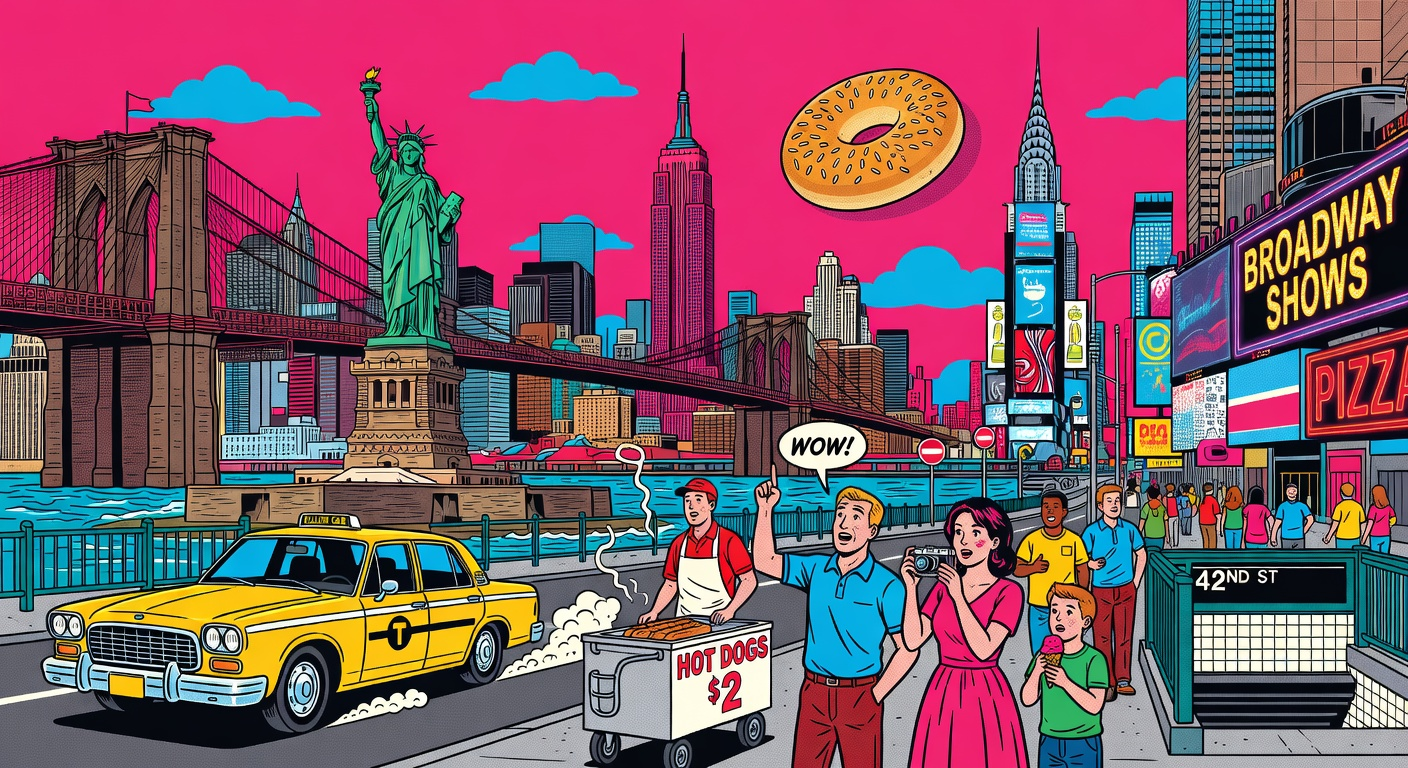

In [35]:
image = artist("New York City")
display(image)

In [37]:
def talker(message):
    response = xai.audio.speech.create(
      model="tts-1",
      voice="ara",
      input=message
    )
    return response.content

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [42]:
def chat(history):
    tools_for_model = get_tools_for_model()
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = xai.chat.completions.create(model=MODEL, messages=messages, tools=tools_for_model)
    print(response)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = xai.chat.completions.create(model=MODEL, messages=messages, tools=tools_for_model)
        print(response)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)
    print("Generated voice response")

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


In [39]:
# def handle_tool_calls_and_return_cities(message):
#     responses = []
#     cities = []
#     for tool_call in message.tool_calls:
#         if tool_call.function.name == "get_ticket_price":
#             arguments = json.loads(tool_call.function.arguments)
#             city = arguments.get('destination_city')
#             cities.append(city)
#             price_details = get_ticket_price(city)
#             responses.append({
#                 "role": "tool",
#                 "content": price_details,
#                 "tool_call_id": tool_call.id
#             })
#     return responses, cities

def handle_tool_calls_and_return_cities(message):
    """Handles tool calls from the model by executing the corresponding functions and returning their results."""
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        print(f"Got tool call {tool_call}")
        func = tools.get(tool_call.function.name, {})
        if func:
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            print(f"Calling function {func['function']} with arguments {arguments}")
            result = func['function'](**arguments)
            print(f"Got result {result} from tool call")
            responses.append({
                "role": "tool",
                "content": result or "",
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [43]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

* Running on local URL:  http://127.0.0.1:7874
* To create a public link, set `share=True` in `launch()`.


ChatCompletion(id='f3eb5a9c-66ad-9eba-ba6d-4050adadc6f0', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Hello! How can I assist you with FlightAI today?', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None))], created=1777747118, model='grok-4-1-fast-non-reasoning', object='chat.completion', service_tier=None, system_fingerprint='fp_870adde9b1', usage=CompletionUsage(completion_tokens=12, prompt_tokens=406, total_tokens=418, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=398, text_tokens=406, image_tokens=0), num_sources_used=0, cost_in_usd_ticks=275000))


Traceback (most recent call last):
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-packages\gradio\queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-packages\gradio\blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-packages\gradio\blocks.py", line 1623, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jordan-dev\repos\llm_engineering\.venv\Lib\site-p

# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>